# GO Enrichment Analysis Overview

This notebook parses a pre-filtered Gene Ontology (GO) enrichment result file (TSV format) and produces a series of plots and tables to help interpret the data. The result file is assumed to already contain gene sets within the desired size limits.

The file is expected to have the following columns:

- **term**: GO identifier
- **name**: GO term name
- **size**: number of measured genes associated with the term
- **is_true**: boolean flag indicating whether the term is a simulated enriched GO entry
- **noverlap**: number of significant genes (SGs) among the measured ones associated with the term
- **hg_pval**: p-value from the hypergeometric test
- **hg_fdr**: Benjamini-Hochberg corrected hypergeometric p-value
- **fej_pval**: p-value from Fischer’s exact test using jack-knifing
- **fej_fdr**: Benjamini-Hochberg corrected Fischer’s p-value
- **ks_stat**: KS test statistic (enrichment score)
- **ks_pval**: p-value from the KS test
- **ks_fdr**: Benjamini-Hochberg corrected KS p-value
- **shortest_path_to_a_true**: if the term is not a true entry, the shortest path in the GO DAG to a true entry

Optionally, if a column named `sg_genes` is available (with gene IDs separated by a delimiter such as `;`), additional analysis on significant gene occurrences will be performed.

Let’s begin by loading the data and generating the plots.

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Use a clean and modern style for plots
sns.set(style="whitegrid", context="talk")
plt.rcParams["figure.figsize"] = (10, 6)

# Path to the result file (adjust this path as needed)
result_file = "../../../../data/GOEnrichment/runs/ensembl_BP_out.tsv"  # e.g., "simul_exp_go_bp_ensembl_min50_max500.enrich.out"

# Read the TSV file into a DataFrame. It is assumed the file has a header.
df = pd.read_csv(result_file, sep="\t")

# Show the first few lines to verify the data
display(df.head())

,term,name,size,is_true,noverlap,hg_pval,hg_fdr,fej_pval,fej_fdr,ks_stat,ks_pval,ks_fdr,shortest_path_to_a_true
0,GO:0000018,regulation of DNA recombination,52,False,23,1.516050e-09,3.407880e-09,6.054530e-09,1.339980e-08,0.233293,0.007102,0.032792,regulation of DNA recombination|regulation of ...
1,GO:1900544,positive regulation of purine nucleotide metab...,95,False,33,1.002900e-09,2.267300e-09,3.148920e-09,7.129110e-09,0.145159,0.037442,0.108808,positive regulation of purine nucleotide metab...
2,GO:0000041,transition metal ion transport,105,False,13,3.892890e-01,4.639720e-01,4.961090e-01,5.912840e-01,0.072828,0.637880,0.750615,transition metal ion transport|metal ion trans...
3,GO:0000075,cell cycle checkpoint,147,False,26,1.161990e-02,1.641560e-02,1.916910e-02,2.734980e-02,0.078134,0.336581,0.506991,cell cycle checkpoint|cellular process|biologi...
4,GO:0000077,DNA damage checkpoint,75,False,10,3.246450e-01,3.946770e-01,4.446780e-01,5.368790e-01,0.076869,0.769965,0.844927,DNA damage checkpoint|DNA integrity checkpoint...


## 1. Distribution of Significant Genes (SGs)

Here we plot a histogram showing the distribution of the number of significant genes (the `noverlap` column) across all gene sets.

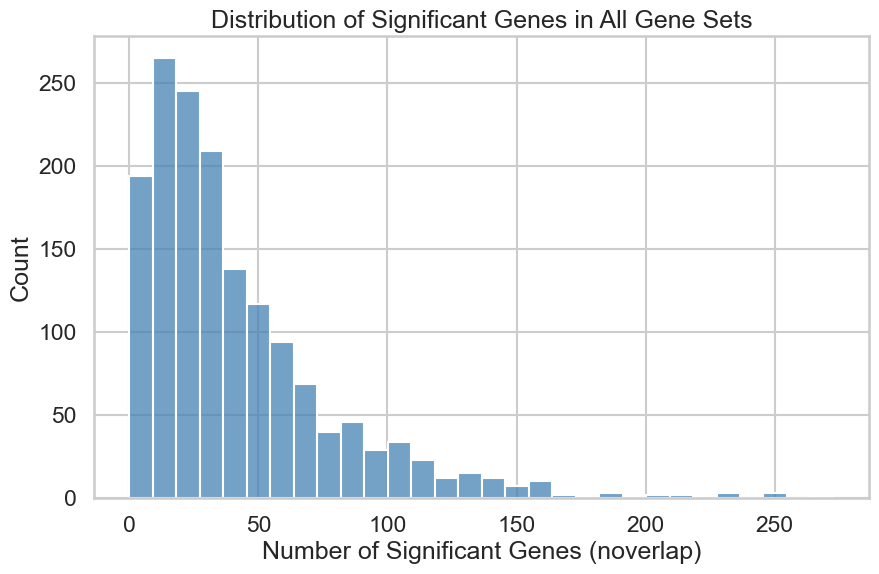

In [6]:
plt.figure()
sns.histplot(df["noverlap"], bins=30, color="steelblue")
plt.title("Distribution of Significant Genes in All Gene Sets")
plt.xlabel("Number of Significant Genes (noverlap)")
plt.ylabel("Count")
plt.show()

## 2. Distribution of Enrichment Scores and P-values

The next section generates histograms for several enrichment metrics:

- **KS Statistic** (`ks_stat`)
- **Hypergeometric p-value** (`hg_pval`)
- **Fischer’s Exact Test p-value** (`fej_pval`)
- **KS Test p-value** (`ks_pval`)

These plots help visualize the overall distribution of the enrichment scores and statistical significance across gene sets.

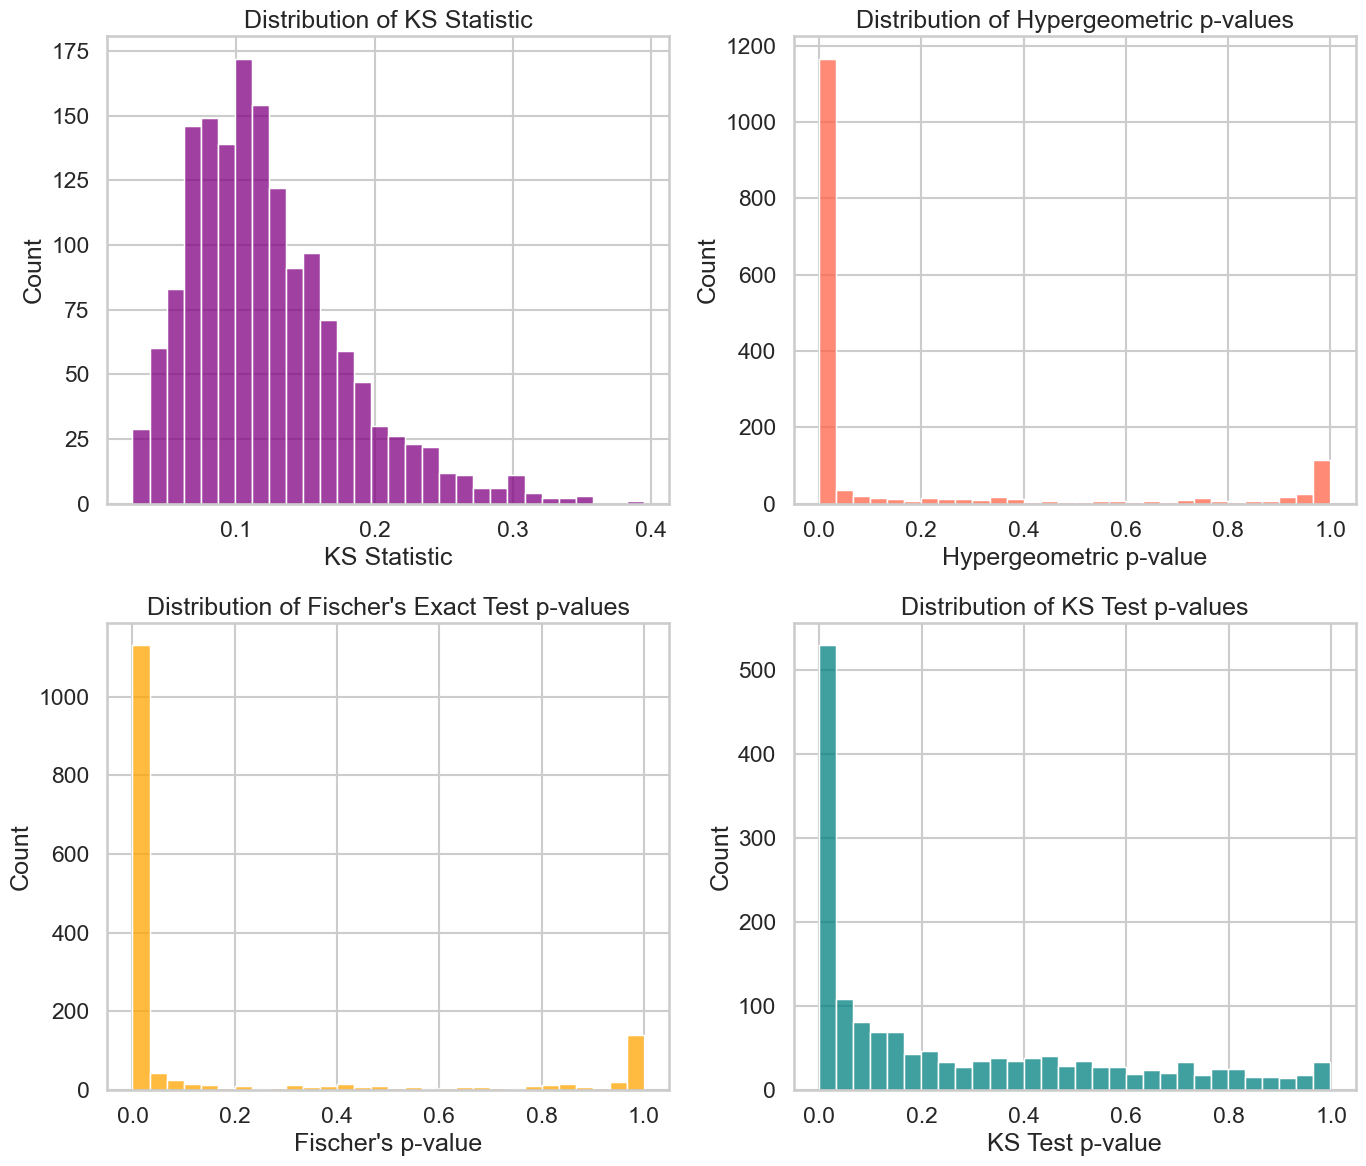

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# KS Statistic
sns.histplot(df["ks_stat"], bins=30, ax=axes[0,0], color="purple")
axes[0,0].set_title("Distribution of KS Statistic")
axes[0,0].set_xlabel("KS Statistic")

# Hypergeometric p-value
sns.histplot(df["hg_pval"], bins=30, ax=axes[0,1], color="tomato")
axes[0,1].set_title("Distribution of Hypergeometric p-values")
axes[0,1].set_xlabel("Hypergeometric p-value")

# Fischer's Exact Test p-value
sns.histplot(df["fej_pval"], bins=30, ax=axes[1,0], color="orange")
axes[1,0].set_title("Distribution of Fischer's Exact Test p-values")
axes[1,0].set_xlabel("Fischer's p-value")

# KS Test p-value
sns.histplot(df["ks_pval"], bins=30, ax=axes[1,1], color="teal")
axes[1,1].set_title("Distribution of KS Test p-values")
axes[1,1].set_xlabel("KS Test p-value")

plt.tight_layout()
plt.show()

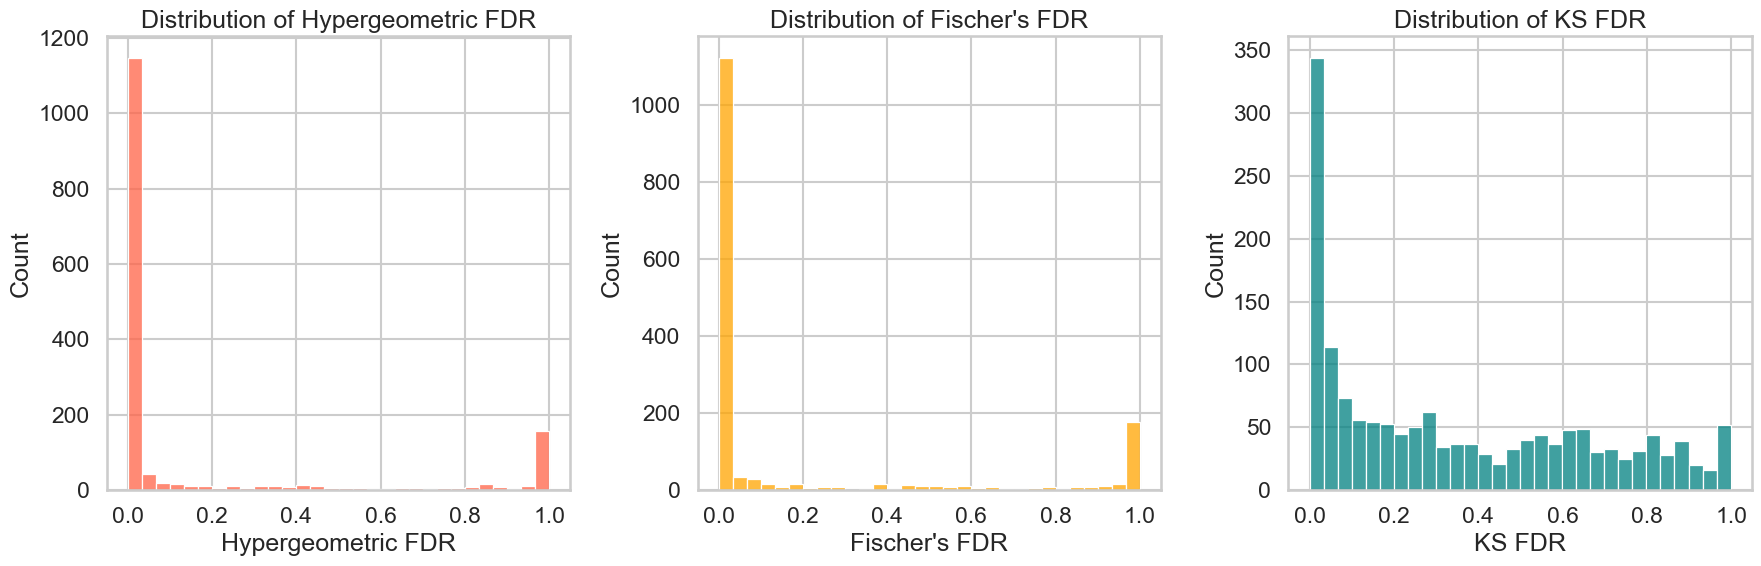

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Hypergeometric FDR
sns.histplot(df["hg_fdr"], bins=30, ax=axes[0], color="tomato")
axes[0].set_title("Distribution of Hypergeometric FDR")
axes[0].set_xlabel("Hypergeometric FDR")

# Fischer's Exact Test FDR
sns.histplot(df["fej_fdr"], bins=30, ax=axes[1], color="orange")
axes[1].set_title("Distribution of Fischer's FDR")
axes[1].set_xlabel("Fischer's FDR")

# KS Test FDR
sns.histplot(df["ks_fdr"], bins=30, ax=axes[2], color="teal")
axes[2].set_title("Distribution of KS FDR")
axes[2].set_xlabel("KS FDR")

plt.tight_layout()
plt.show()


## 3. Scatter Plots: Enrichment Metrics vs. Gene Set Size

### A. KS Statistic vs. Gene Set Size

This plot shows how the enrichment score (KS statistic) relates to the number of genes in each set.

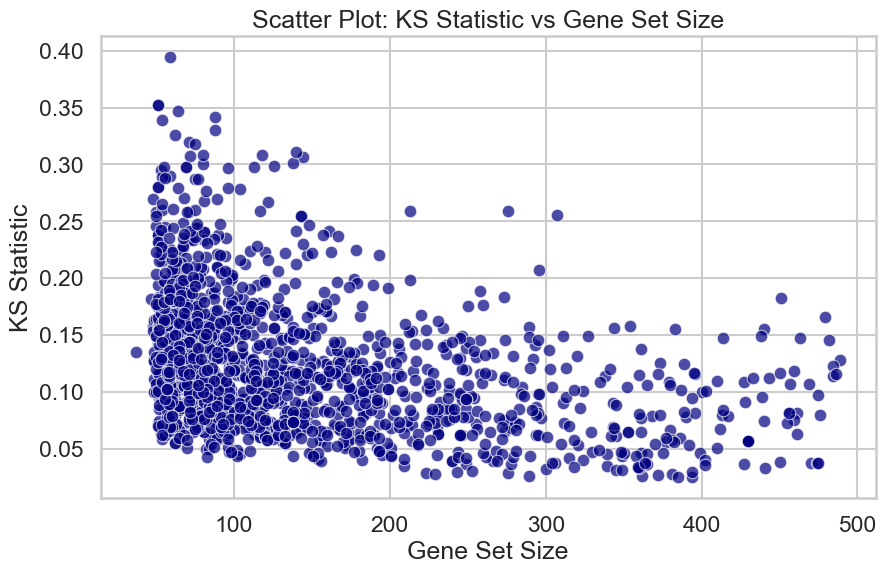

In [8]:
plt.figure()
sns.scatterplot(data=df, x="size", y="ks_stat", color="navy", alpha=0.7)
plt.title("Scatter Plot: KS Statistic vs Gene Set Size")
plt.xlabel("Gene Set Size")
plt.ylabel("KS Statistic")
plt.show()

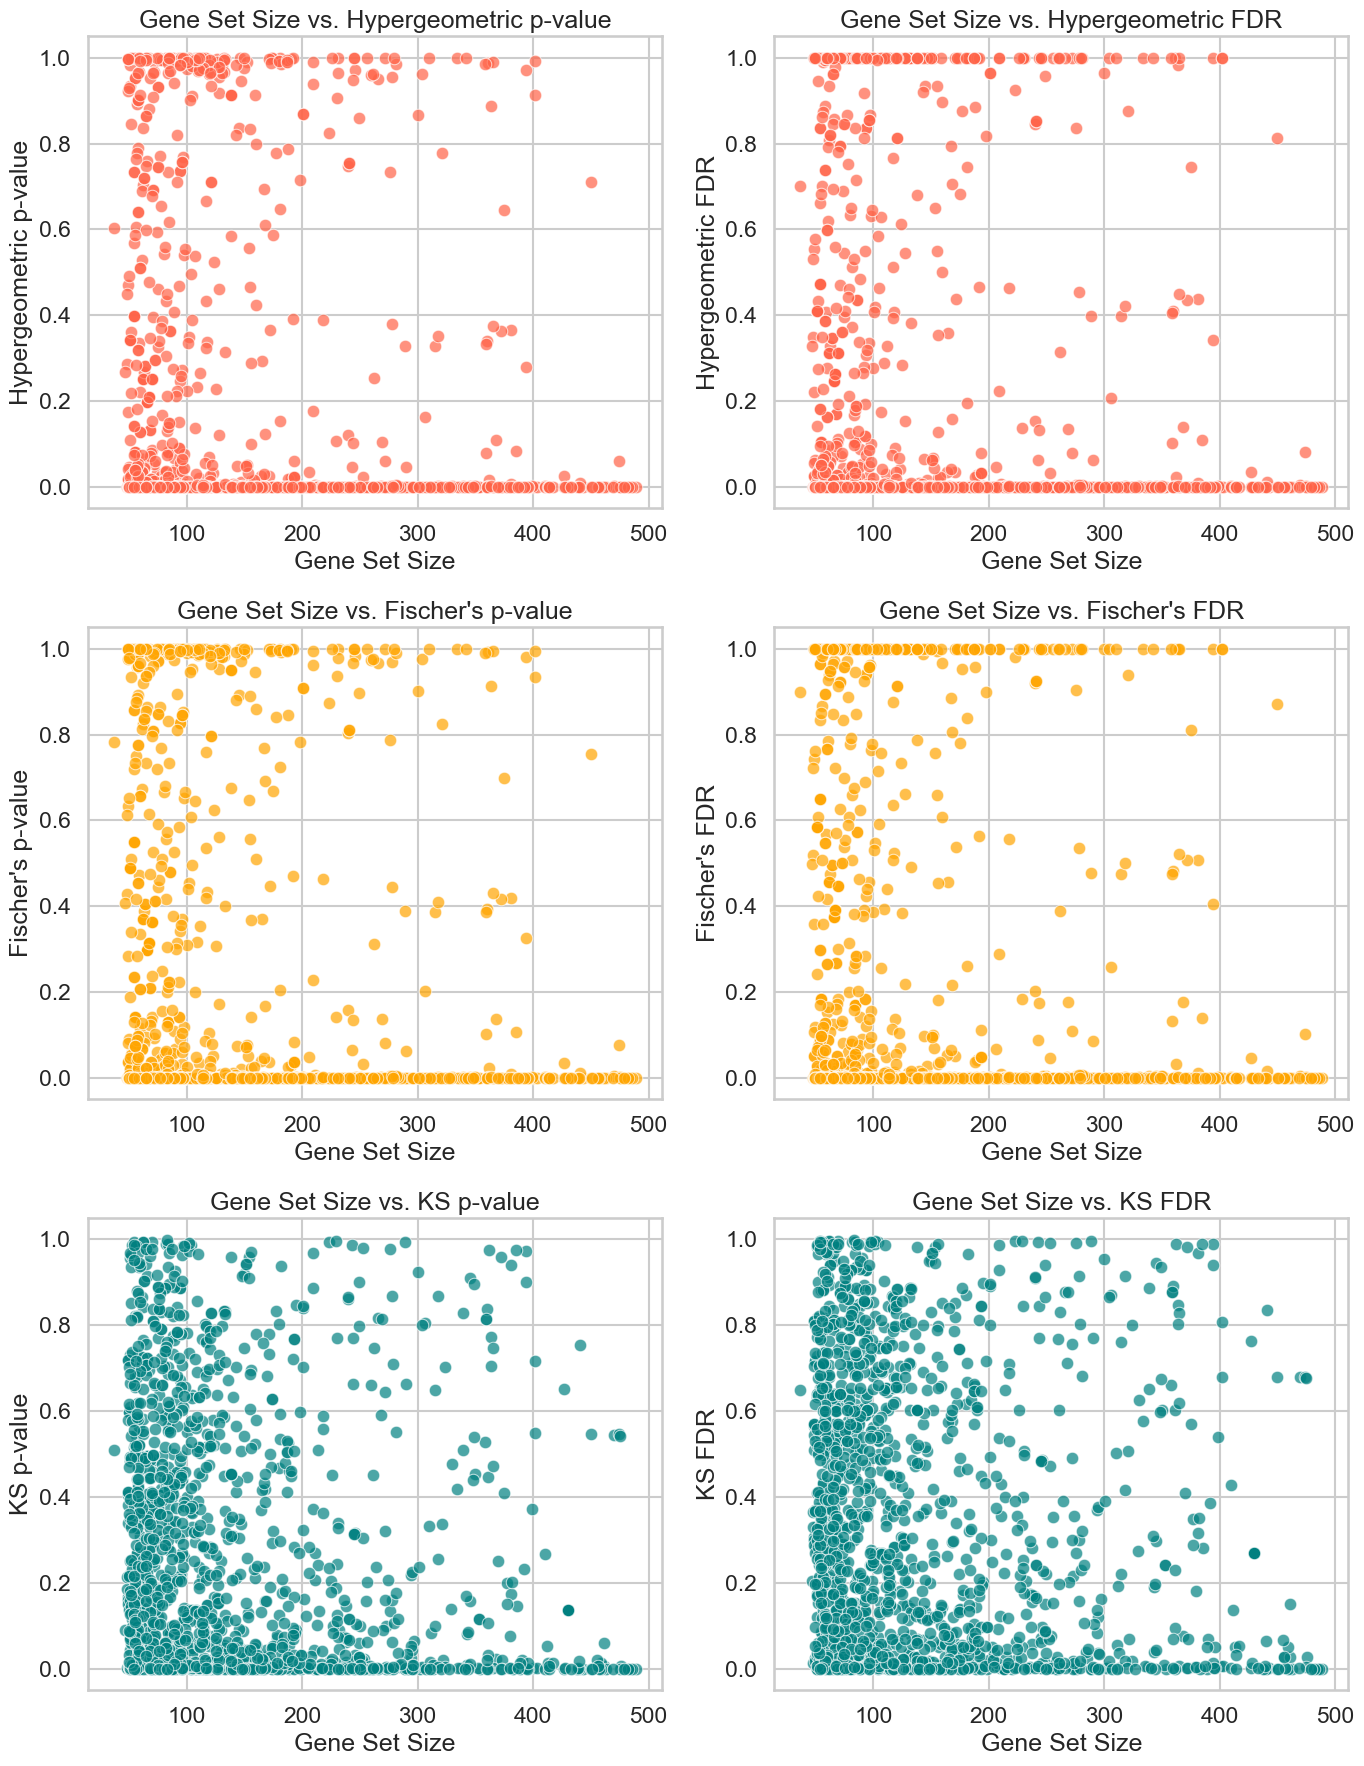

In [13]:
fig, axes = plt.subplots(3, 2, figsize=(14, 18))

# Scatter: Gene Set Size vs. Hypergeometric p-value
sns.scatterplot(data=df, x="size", y="hg_pval", ax=axes[0,0], color="tomato", alpha=0.7)
axes[0,0].set_title("Gene Set Size vs. Hypergeometric p-value")
axes[0,0].set_xlabel("Gene Set Size")
axes[0,0].set_ylabel("Hypergeometric p-value")

# Scatter: Gene Set Size vs. Hypergeometric FDR
sns.scatterplot(data=df, x="size", y="hg_fdr", ax=axes[0,1], color="tomato", alpha=0.7)
axes[0,1].set_title("Gene Set Size vs. Hypergeometric FDR")
axes[0,1].set_xlabel("Gene Set Size")
axes[0,1].set_ylabel("Hypergeometric FDR")

# Scatter: Gene Set Size vs. Fischer's p-value
sns.scatterplot(data=df, x="size", y="fej_pval", ax=axes[1,0], color="orange", alpha=0.7)
axes[1,0].set_title("Gene Set Size vs. Fischer's p-value")
axes[1,0].set_xlabel("Gene Set Size")
axes[1,0].set_ylabel("Fischer's p-value")

# Scatter: Gene Set Size vs. Fischer's FDR
sns.scatterplot(data=df, x="size", y="fej_fdr", ax=axes[1,1], color="orange", alpha=0.7)
axes[1,1].set_title("Gene Set Size vs. Fischer's FDR")
axes[1,1].set_xlabel("Gene Set Size")
axes[1,1].set_ylabel("Fischer's FDR")

# Scatter: Gene Set Size vs. KS p-value
sns.scatterplot(data=df, x="size", y="ks_pval", ax=axes[2,0], color="teal", alpha=0.7)
axes[2,0].set_title("Gene Set Size vs. KS p-value")
axes[2,0].set_xlabel("Gene Set Size")
axes[2,0].set_ylabel("KS p-value")

# Scatter: Gene Set Size vs. KS FDR
sns.scatterplot(data=df, x="size", y="ks_fdr", ax=axes[2,1], color="teal", alpha=0.7)
axes[2,1].set_title("Gene Set Size vs. KS FDR")
axes[2,1].set_xlabel("Gene Set Size")
axes[2,1].set_ylabel("KS FDR")

plt.tight_layout()
plt.show()

### B. Hypergeometric p-value vs. Gene Set Size

This plot explores the relationship between gene set size and the hypergeometric p-value.

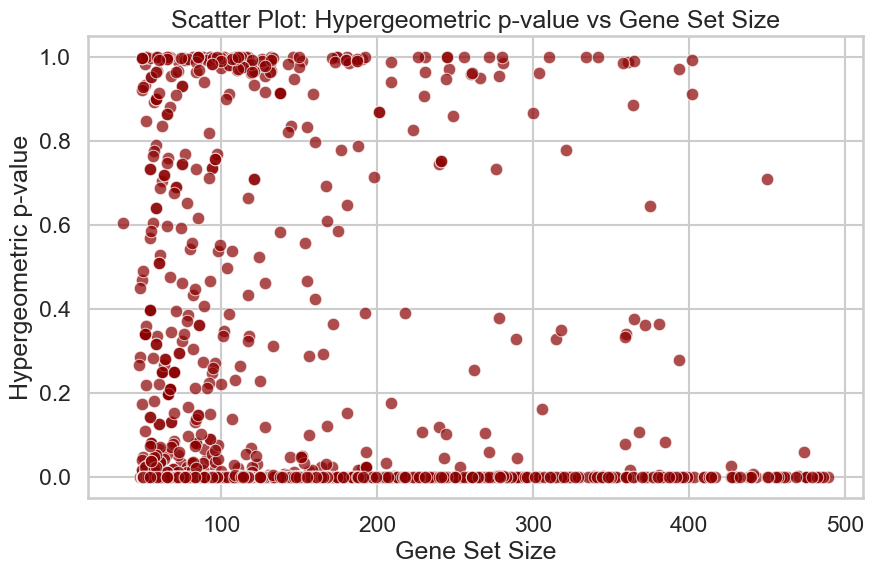

In [9]:
plt.figure()
sns.scatterplot(data=df, x="size", y="hg_pval", color="darkred", alpha=0.7)
plt.title("Scatter Plot: Hypergeometric p-value vs Gene Set Size")
plt.xlabel("Gene Set Size")
plt.ylabel("Hypergeometric p-value")
plt.show()

## 4. Sorted Tables of Gene Sets

Below are examples of sorted tables (displaying the top 10 entries) according to different criteria.

In [10]:
# Sorted by number of significant genes (noverlap)
df_sorted_noverlap = df.sort_values(by="noverlap", ascending=False)
print("Top 10 Gene Sets Sorted by Number of Significant Genes (noverlap):")
display(df_sorted_noverlap[["term", "name", "noverlap"]].head(10))

# Sorted by KS Statistic (enrichment score)
df_sorted_ks = df.sort_values(by="ks_stat", ascending=False)
print("Top 10 Gene Sets Sorted by KS Statistic:")
display(df_sorted_ks[["term", "name", "ks_stat"]].head(10))

# Sorted by Hypergeometric p-value (lowest p-values first)
df_sorted_hg = df.sort_values(by="hg_pval", ascending=True)
print("Top 10 Gene Sets Sorted by Hypergeometric p-value:")
display(df_sorted_hg[["term", "name", "hg_pval"]].head(10))

Top 10 Gene Sets Sorted by Number of Significant Genes (noverlap):


,term,name,noverlap
1434,GO:0051051,negative regulation of transport,273
1548,GO:0060341,regulation of cellular localization,252
1431,GO:0051046,regulation of secretion,249
1458,GO:0051223,regulation of protein transport,248
1018,GO:2000145,regulation of cell motility,233
152,GO:0002683,negative regulation of immune system process,232
196,GO:1903530,regulation of secretion by cell,232
853,GO:0030334,regulation of cell migration,221
831,GO:0030155,regulation of cell adhesion,214
1246,GO:0045596,negative regulation of cell differentiation,211


Top 10 Gene Sets Sorted by KS Statistic:


,term,name,ks_stat
1314,GO:0046823,negative regulation of nucleocytoplasmic trans...,0.394517
1119,GO:0042308,negative regulation of protein import into nuc...,0.352622
222,GO:1904590,negative regulation of protein import,0.352622
814,GO:0090317,negative regulation of intracellular protein t...,0.346776
210,GO:1903828,negative regulation of cellular protein locali...,0.341620
1572,GO:1900181,negative regulation of protein localization to...,0.339573
958,GO:0032845,negative regulation of homeostatic process,0.330128
1351,GO:0048640,negative regulation of developmental growth,0.325991
69,GO:1902106,negative regulation of leukocyte differentiation,0.319538
940,GO:0032387,negative regulation of intracellular transport,0.317718


Top 10 Gene Sets Sorted by Hypergeometric p-value:


,term,name,hg_pval
1434,GO:0051051,negative regulation of transport,4.339600e-226
152,GO:0002683,negative regulation of immune system process,8.861960e-179
1275,GO:0045926,negative regulation of growth,8.056330e-126
1548,GO:0060341,regulation of cellular localization,2.774930e-124
229,GO:1904950,negative regulation of establishment of protei...,2.040150e-122
1459,GO:0051224,negative regulation of protein transport,1.449950e-118
1431,GO:0051046,regulation of secretion,3.253800e-112
1458,GO:0051223,regulation of protein transport,4.927360e-112
196,GO:1903530,regulation of secretion by cell,8.941510e-107
1102,GO:0040013,negative regulation of locomotion,1.704470e-104


## 5. Analysis of Significant Gene Occurrence Across Gene Sets (Optional)

If the result file includes a column named `sg_genes` (with gene IDs separated by a delimiter such as `;`), the following cell will analyze how often each significant gene appears across the gene sets. If the column is not present, this section is skipped.

In [11]:
if "sg_genes" in df.columns:
    # Split the gene lists and count occurrences
    sg_series = df["sg_genes"].dropna().str.split(";").explode()
    sg_counts = sg_series.value_counts()

    # Plot the distribution of the number of gene sets per significant gene
    plt.figure()
    sns.histplot(sg_counts, bins=30, color="mediumseagreen")
    plt.title("Distribution of Number of Gene Sets per Significant Gene")
    plt.xlabel("Number of Sets a Gene Appears In")
    plt.ylabel("Count of Genes")
    plt.show()

    # Report the number of genes that appear uniquely (only in one gene set)
    unique_sg = sg_counts[sg_counts == 1]
    print(f"Number of unique significant genes (appearing in only one set): {len(unique_sg)}")
else:
    print("Column 'sg_genes' not found in the result file; skipping analysis of significant gene occurrence.")

Column 'sg_genes' not found in the result file; skipping analysis of significant gene occurrence.


## Final Remarks

This notebook provides an overview of the GO enrichment results using various plots and sorted tables. Adjust file paths and column names as needed if your result file structure differs.

To run this notebook:

1. Save this content in a file named (for example) `go_enrichment_analysis.ipynb`.
2. Launch Jupyter Notebook or JupyterLab.
3. Open the saved notebook and run all cells.

The visualizations include clear titles and axis labels to support the scientific interpretation of your data.